In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("E:\CLV_Project\online_retail_II.csv")

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\hp\AppData\Local\Temp\ipykernel_6480\1118451674.py:1: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv("E:\CLV_Project\online_retail_II.csv")


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,Lifespan,PurchaseFrequency,Recency_Frequency,Monetary_Frequency,CLV_Segment
0,12347.0,2,8,4921.53,22.169054,402,0.019851,16,39372.24,2
1,12348.0,75,5,2019.40,39.596078,362,0.013774,375,10097.00,2
2,12349.0,19,4,4428.69,25.306800,570,0.007005,76,17714.76,2
3,12350.0,310,1,334.40,19.670588,0,1.000000,310,334.40,0
4,12351.0,375,1,300.93,14.330000,0,1.000000,375,300.93,0


In [4]:
X = df.drop(["Customer ID", "CLV_Segment"], axis=1)
y = df["CLV_Segment"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.961340206185567


In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9991408934707904


In [9]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_acc)

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:49:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9982817869415808


In [10]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [lr_acc, rf_acc, xgb_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.961340
1,Random Forest,0.999141
2,XGBoost,0.998282


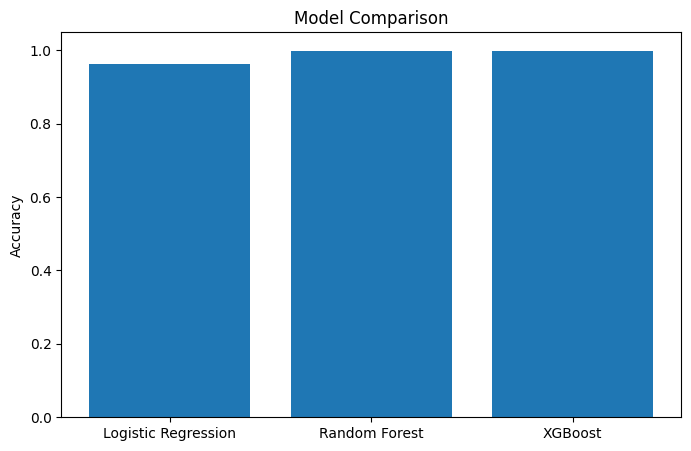

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()